In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [2]:
#%%
#PCA
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
data.keys()
 


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
# Check the output classes
print(data['target_names'])
 
# Check the input attributes
print(data['feature_names'])


# construct a dataframe using pandas
df1=pd.DataFrame(data['data'],columns=data['feature_names'])

['malignant' 'benign']
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [5]:
df1.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
#%% 
# Scale data before applying PCA
scaling=StandardScaler()
 
# Use fit and transform method 
scaling.fit(df1)

Scaled_data=scaling.transform(df1)

In [7]:
Scaled_data

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [8]:
from sklearn.decomposition import PCA
# Set the n_components=2
principal=PCA(n_components=4)
# principal.fit(Scaled_data)
x=principal.fit_transform(Scaled_data)
 
# Check the dimensions of data after PCA
print(x.shape)

(569, 4)


In [12]:
principal

PCA(n_components=4)

In [ ]:
x

array([[ 9.19283683,  1.94858307, -1.12316616, -3.6337309 ],
       [ 2.3878018 , -3.76817174, -0.52929269, -1.11826386],
       [ 5.73389628, -1.0751738 , -0.55174759, -0.91208267],
       ...,
       [ 1.25617928, -1.90229671,  0.56273053,  2.08922702],
       [10.37479406,  1.67201011, -1.87702933,  2.35603113],
       [-5.4752433 , -0.67063679,  1.49044308,  2.29915714]])

In [9]:
#%%
print(principal.explained_variance_ratio_)
print(np.sum(principal.explained_variance_ratio_))

[0.44272026 0.18971182 0.09393163 0.06602135]
0.7923850582446098


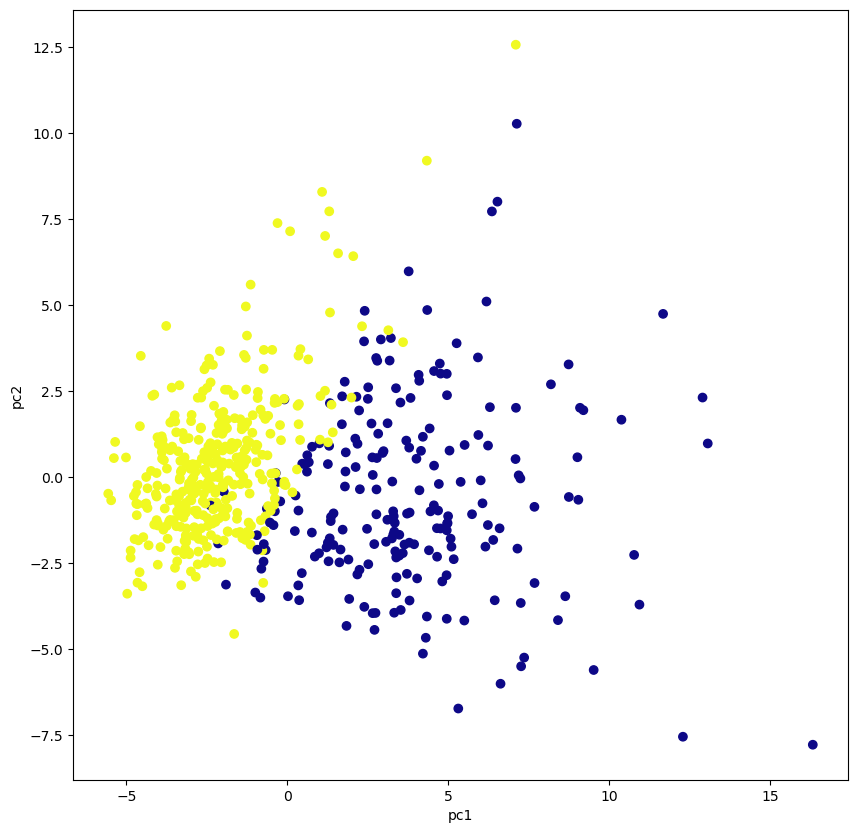

In [18]:
#%%
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.scatter(x[:,0],x[:,1],c=data['target'],cmap='plasma')
plt.xlabel('pc1')
plt.ylabel('pc2')

plt.show()

In [10]:
#%% Train with whole data
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [18]:
X = Scaled_data
y = data['target']

test_data = 0.2
seed = 10
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_data, random_state=seed)

In [19]:
classifier = LogisticRegression() 
classifier.fit(X_train, y_train) 

LogisticRegression()

In [20]:
y_pred = classifier.predict(X_test) 

In [21]:
print("Logistic Regression model accuracy(in %):",
      accuracy_score(y_test, y_pred)*100)

Logistic Regression model accuracy(in %): 96.49122807017544


In [22]:
#%% Train with PCA
X = x
y = data['target']

test_data = 0.2
seed = 10
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_data, random_state=seed)

In [23]:
classifier1 = LogisticRegression() 
classifier1.fit(X_train, y_train) 

LogisticRegression()

In [24]:
y_pred = classifier1.predict(X_test) 

In [25]:
print("Logistic Regression model accuracy(in %):",
      accuracy_score(y_test, y_pred)*100)

Logistic Regression model accuracy(in %): 96.49122807017544


In [30]:
from sklearn.manifold import TSNE

model = TSNE(n_components = 2, random_state = 10)

tsne_data = model.fit_transform(Scaled_data)

In [31]:
X = tsne_data
y = data['target']

test_data = 0.2
seed = 10
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_data, random_state=seed)

In [32]:
classifier = LogisticRegression() 
classifier.fit(X_train, y_train) 


LogisticRegression()

In [33]:
y_pred = classifier.predict(X_test) 

In [34]:
print("Logistic Regression model accuracy(in %):",
      accuracy_score(y_test, y_pred)*100)

Logistic Regression model accuracy(in %): 97.36842105263158


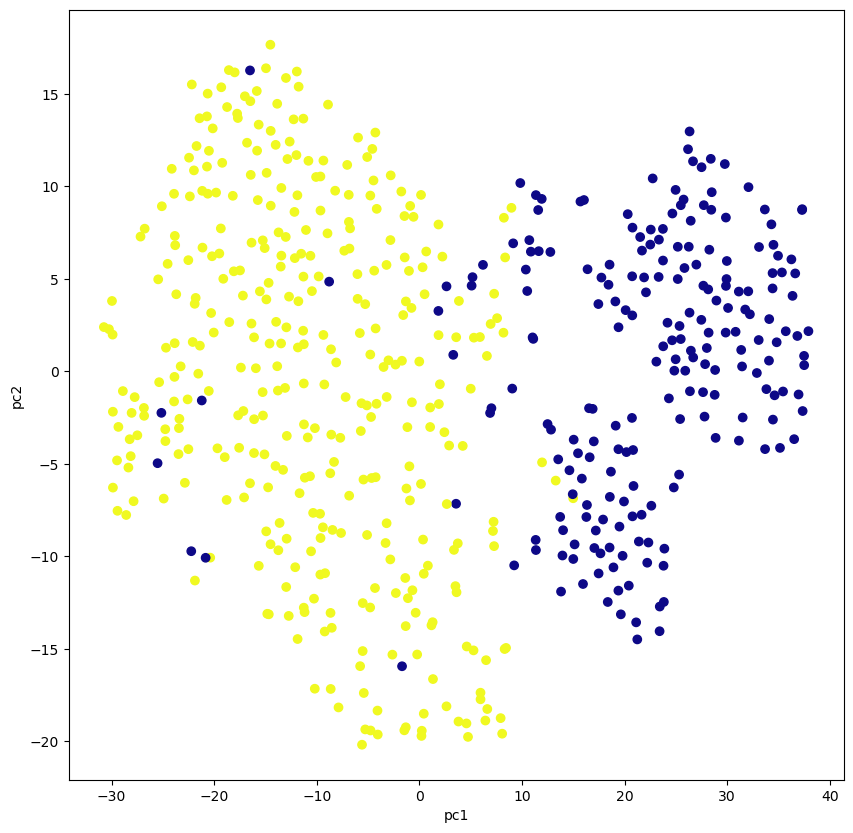

In [35]:
#%%
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.scatter(tsne_data[:,0],tsne_data[:,1],c=data['target'],cmap='plasma')
plt.xlabel('pc1')
plt.ylabel('pc2')

plt.show()